In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

# Load saved data from Phase 2
with open('../data/X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('../data/X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open('../data/y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('../data/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)
with open('../data/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Data loaded successfully!
X_train shape: (35898, 20)
X_test shape:  (6519, 20)


## Train all 3 models

In [2]:
# Define all 3 models
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='logloss', verbosity=0)
}

# Train and evaluate each model
results = {}
print("Training models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Evaluate
    results[name] = {
        'model': model,
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'F1-Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }
    
    print(f"  ROC-AUC:   {results[name]['ROC-AUC']:.4f}")
    print(f"  F1-Score:  {results[name]['F1-Score']:.4f}")
    print(f"  Precision: {results[name]['Precision']:.4f}")
    print(f"  Recall:    {results[name]['Recall']:.4f}")
    print()

print("All models trained!")

Training models...

Training Logistic Regression...
  ROC-AUC:   0.9061
  F1-Score:  0.7555
  Precision: 0.6820
  Recall:    0.8469

Training Random Forest...
  ROC-AUC:   0.9341
  F1-Score:  0.7928
  Precision: 0.7430
  Recall:    0.8498

Training XGBoost...
  ROC-AUC:   0.9369
  F1-Score:  0.7890
  Precision: 0.7501
  Recall:    0.8321

All models trained!


## Compare models visually

=== Model Comparison ===
                     ROC-AUC  F1-Score  Precision  Recall
Logistic Regression   0.9061    0.7555     0.6820  0.8469
Random Forest         0.9341    0.7928     0.7430  0.8498
XGBoost               0.9369    0.7890     0.7501  0.8321


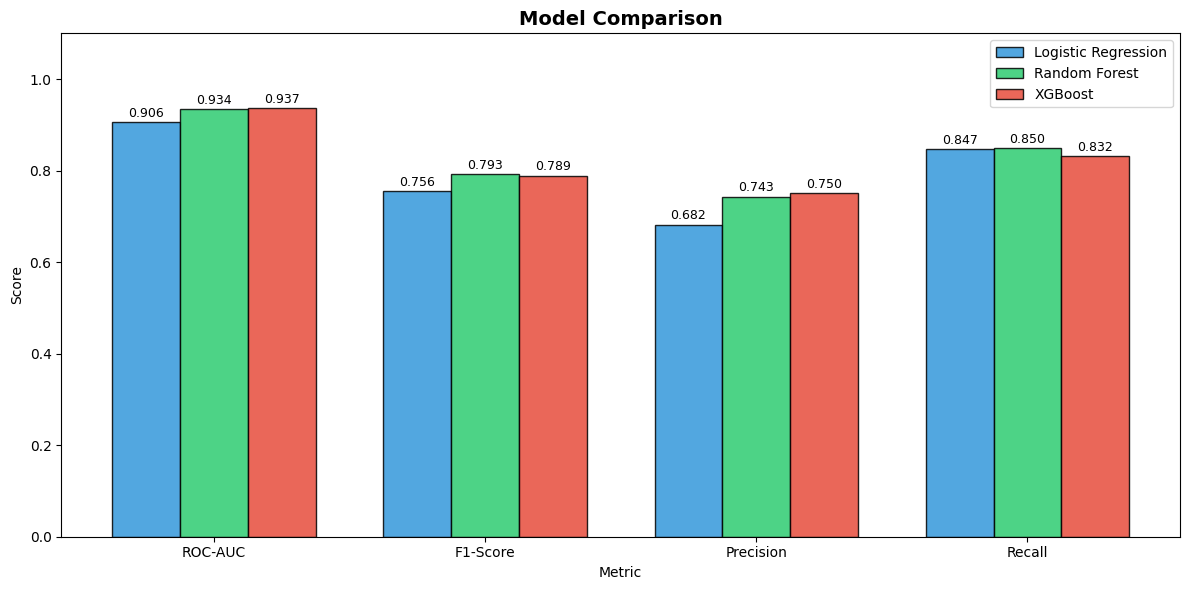

In [3]:
# Build comparison dataframe
metrics = ['ROC-AUC', 'F1-Score', 'Precision', 'Recall']
comparison_df = pd.DataFrame({
    name: {m: results[name][m] for m in metrics}
    for name in results
}).T

print("=== Model Comparison ===")
print(comparison_df.round(4))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, 
                  label=name, color=color, alpha=0.85, edgecolor='black')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

## ROC Curve for all models

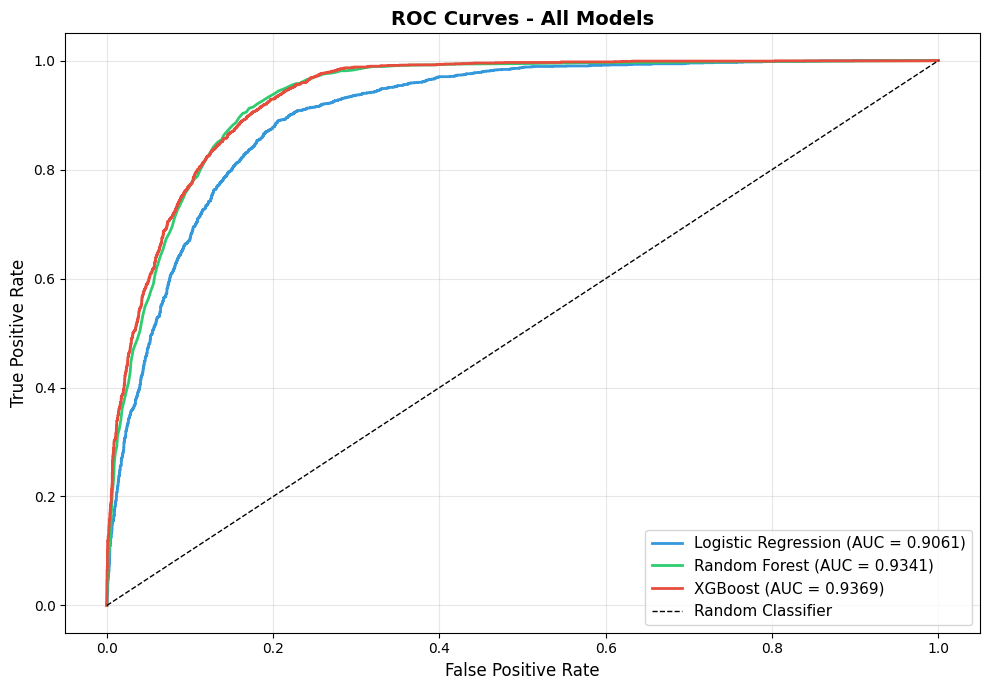

In [4]:
plt.figure(figsize=(10, 7))

for name, color in zip(results.keys(), ['#3498db', '#2ecc71', '#e74c3c']):
    model = results[name]['model']
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results[name]['ROC-AUC']
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150)
plt.show()

## Hyperparameter tune the best model

In [5]:
print("Tuning XGBoost (best model)...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(
    random_state=42, eval_metric='logloss', verbosity=0)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")

Tuning XGBoost (best model)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.9659


## Evaluate tuned model

=== Tuned XGBoost Results ===
ROC-AUC:   0.9378
F1-Score:  0.7862
Precision: 0.7511
Recall:    0.8247

=== Classification Report ===
              precision    recall  f1-score   support

 Not Dropout       0.92      0.88      0.90      4488
     Dropout       0.75      0.82      0.79      2031

    accuracy                           0.86      6519
   macro avg       0.83      0.85      0.84      6519
weighted avg       0.87      0.86      0.86      6519



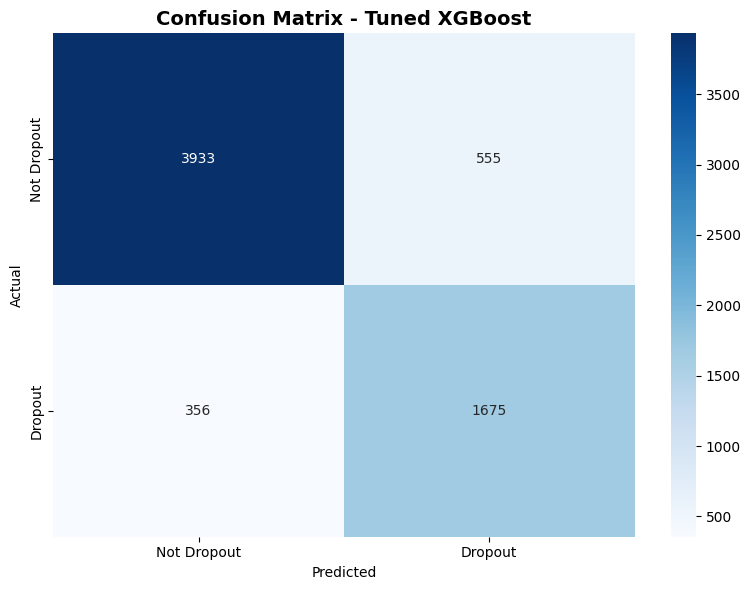

In [6]:
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("=== Tuned XGBoost Results ===")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_best,
      target_names=['Not Dropout', 'Dropout']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Dropout', 'Dropout'],
            yticklabels=['Not Dropout', 'Dropout'])
plt.title('Confusion Matrix - Tuned XGBoost',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

## Feature importance

=== Top 10 Most Important Features ===
                      feature  importance
13          total_assessments    0.477207
11                  max_score    0.063195
6         code_module_encoded    0.060771
0              gender_encoded    0.040914
7   code_presentation_encoded    0.037256
16                active_days    0.032562
8        num_of_prev_attempts    0.032477
9             studied_credits    0.025793
2   highest_education_encoded    0.024375
15               total_clicks    0.023153


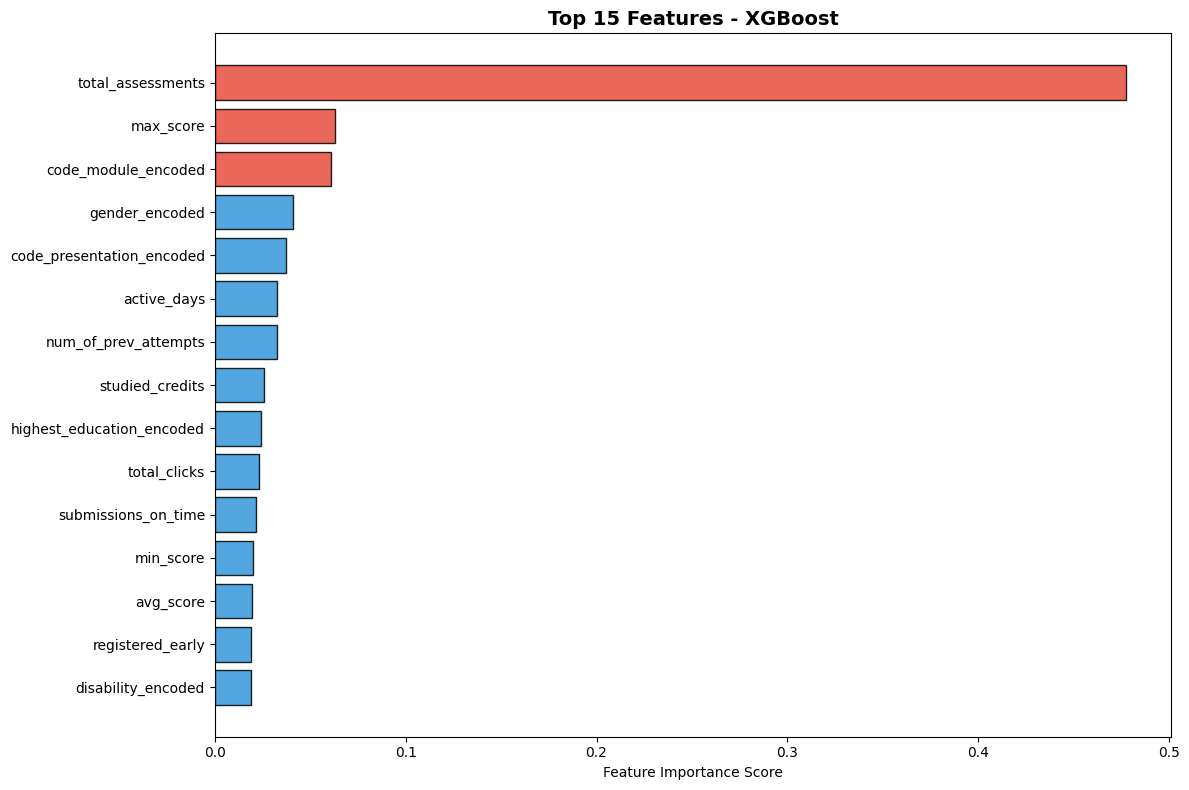

In [7]:
# Get feature importances
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("=== Top 10 Most Important Features ===")
print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(15)
colors = ['#e74c3c' if i < 3 else '#3498db' 
          for i in range(len(top_features))]

plt.barh(range(len(top_features)), 
         top_features['importance'].values,
         color=colors, edgecolor='black', alpha=0.85)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Features - XGBoost', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

In [9]:
# Save best model
with open('../data/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("=" * 50)
print("      FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Model:      Tuned XGBoost Classifier")
print(f"Features:   {len(feature_cols)}")
print(f"Train size: {X_train.shape[0]:,} (after SMOTE)")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"F1-Score:   {f1_score(y_test, y_pred_best):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred_best):.4f}")
print("=" * 50)
print("\nModel saved to ../data/best_model.pkl")

      FINAL MODEL SUMMARY
Model:      Tuned XGBoost Classifier
Features:   20
Train size: 35,898 (after SMOTE)
Test size:  6,519
ROC-AUC:    0.9378
F1-Score:   0.7862
Precision:  0.7511
Recall:     0.8247

Model saved to ../data/best_model.pkl
